# 02. View Validation & Quality Gate Training

Ноутбук сохранён под старым смысловым названием `quality_view`, но внутри обучает **две отдельные модели**:

1. `view_validation` — проверка ракурса обязательного фото  
2. `quality_gate` — бинарная проверка качества `accept / reject`

Никакого multitask-loss и никаких фейковых меток.

In [1]:

!pip install -q torch torchvision timm scikit-learn matplotlib pandas pyyaml tqdm

In [2]:

import os
import sys
import json
import time
import math
import random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score
import timm

In [3]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for cand in [start] + list(start.parents):
        if any((cand / m).exists() for m in ["pyproject.toml", "requirements.txt", ".git"]):
            return cand
    return start.parent if start.parent.exists() else start

PROJECT_ROOT = find_project_root(Path("."))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = PROJECT_ROOT / "ml" / "data"
VIEW_DATASET_DIR = DATA_ROOT / "view_dataset"
QUALITY_DATASET_DIR = DATA_ROOT / "quality_dataset"

QUALITY_VIEW_ROOT = PROJECT_ROOT / "ml" / "quality_view"
CONFIGS_DIR = QUALITY_VIEW_ROOT / "configs"
WEIGHTS_DIR = QUALITY_VIEW_ROOT / "weights"
REPORTS_DIR = QUALITY_VIEW_ROOT / "reports"
for p in [CONFIGS_DIR, WEIGHTS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("PROJECT_ROOT =", PROJECT_ROOT)
print("DEVICE       =", DEVICE)

PROJECT_ROOT = /Users/versache-karinndzi/Downloads/car-inspection-assistant
DEVICE       = mps


In [4]:
class AddGaussianNoise:
    def __init__(self, std=0.02, p=0.25):
        self.std = std
        self.p = p
    def __call__(self, x):
        if random.random() < self.p:
            noise = torch.randn_like(x) * self.std
            x = torch.clamp(x + noise, 0.0, 1.0)
        return x

def running_in_notebook():
    return "ipykernel" in sys.modules

def recommended_num_workers(default_workers=2):
    # На macOS/Windows + Jupyter PyTorch DataLoader использует spawn(),
    # а кастомные классы/функции из ноутбука должны сериализоваться через pickle.
    # Это часто ломается с ошибками вида:
    # "AttributeError: Can't get attribute ... on <module '__main__'>"
    # Поэтому для ноутбука на MacBook безопаснее num_workers=0.
    if running_in_notebook() and sys.platform in {"darwin", "win32"}:
        return 0
    return default_workers

SAFE_NUM_WORKERS = recommended_num_workers(default_workers=2)

VIEW_CFG = {
    "model_name": "efficientnet_b0",
    "image_size": 224,
    "batch_size": 24 if DEVICE == "cuda" else 12,
    "epochs": 16 if DEVICE == "cuda" else 10,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "num_workers": SAFE_NUM_WORKERS,
    "patience": 4,
    "confidence_threshold_candidates": [round(x, 2) for x in np.arange(0.40, 0.91, 0.05)],
}
QUALITY_CFG = {
    "model_name": "efficientnet_b0",
    "image_size": 224,
    "batch_size": 24 if DEVICE == "cuda" else 12,
    "epochs": 14 if DEVICE == "cuda" else 9,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "num_workers": SAFE_NUM_WORKERS,
    "patience": 4,
    "reject_threshold_candidates": [round(x, 2) for x in np.arange(0.30, 0.91, 0.05)],
}

print(f"Detected platform={sys.platform}, notebook={running_in_notebook()}, num_workers={SAFE_NUM_WORKERS}")

(CONFIGS_DIR / "view_validation_config.json").write_text(json.dumps(VIEW_CFG, indent=2), encoding="utf-8")
(CONFIGS_DIR / "quality_gate_config.json").write_text(json.dumps(QUALITY_CFG, indent=2), encoding="utf-8")

Detected platform=darwin, notebook=True, num_workers=0


333

## Важно для macOS / Jupyter

В этом ноутбуке `num_workers` для `DataLoader` автоматически ставится в `0` на macOS/Windows внутри Jupyter.  
Причина: PyTorch на этих платформах использует `spawn()`, а объекты из ноутбука (`__main__`) должны сериализоваться через pickle.  
Кастомный transform `AddGaussianNoise` из ноутбука при `num_workers > 0` часто приводит к ошибке:

`AttributeError: Can't get attribute 'AddGaussianNoise' on <module '__main__'>`

Это соответствует документации PyTorch и Python multiprocessing: на macOS/Windows при multi-process loading используются отдельные интерпретаторы и pickle-сериализация. citeturn543701search0turn543701search6


## Общие утилиты

In [5]:

def imagefolder_counts(dataset):
    counts = {cls_name: 0 for cls_name in dataset.classes}
    for _, y in dataset.samples:
        counts[dataset.classes[y]] += 1
    return counts

def build_weighted_sampler(dataset):
    counts = imagefolder_counts(dataset)
    class_to_weight = {cls: 1.0 / max(1, cnt) for cls, cnt in counts.items()}
    weights = [class_to_weight[dataset.classes[y]] for _, y in dataset.samples]
    return WeightedRandomSampler(weights=torch.DoubleTensor(weights), num_samples=len(weights), replacement=True)

def create_model(model_name: str, num_classes: int):
    model = timm.create_model(model_name, pretrained=True, num_classes=num_classes)
    return model

def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        probs = logits.softmax(dim=1)
        preds = probs.argmax(dim=1)

        running_loss += loss.item() * x.size(0)
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(preds.cpu().numpy().tolist())
        y_prob.extend(probs.cpu().numpy().tolist())

    loss = running_loss / max(1, len(loader.dataset))
    return {
        "loss": loss,
        "y_true": np.array(y_true),
        "y_pred": np.array(y_pred),
        "y_prob": np.array(y_prob),
    }

def train_classifier(model, train_loader, val_loader, cfg, device, run_name):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    criterion = nn.CrossEntropyLoss()
    best = {"state": None, "score": -1.0, "epoch": -1, "val": None}
    patience = cfg["patience"]
    bad_epochs = 0

    for epoch in range(cfg["epochs"]):
        model.train()
        running_loss, running_acc = 0.0, 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad(set_to_none=True)
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_acc += accuracy_from_logits(logits, y) * x.size(0)

        train_loss = running_loss / max(1, len(train_loader.dataset))
        train_acc = running_acc / max(1, len(train_loader.dataset))
        val_out = evaluate_model(model, val_loader, device)
        val_f1 = f1_score(val_out["y_true"], val_out["y_pred"], average="macro")

        print(
            f"[{run_name}] epoch={epoch+1:02d} "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
            f"val_loss={val_out['loss']:.4f} val_macro_f1={val_f1:.4f}"
        )

        if val_f1 > best["score"]:
            best.update({"state": {k: v.cpu().clone() for k, v in model.state_dict().items()},
                         "score": float(val_f1), "epoch": epoch + 1, "val": val_out})
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stopping after {epoch+1} epochs")
                break

    model.load_state_dict(best["state"])
    return model, best

def plot_confusion(cm, classes, title):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(classes)))
    ax.set_xticklabels(classes, rotation=45, ha="right")
    ax.set_yticks(range(len(classes)))
    ax.set_yticklabels(classes)
    ax.set_title(title)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()

## A. Обучение view validation

In [6]:
view_train_tfms = transforms.Compose([
    transforms.Resize((VIEW_CFG["image_size"], VIEW_CFG["image_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=5),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.05),
    transforms.ToTensor(),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.2))], p=0.18),
    AddGaussianNoise(std=0.02, p=0.20),
])

view_eval_tfms = transforms.Compose([
    transforms.Resize((VIEW_CFG["image_size"], VIEW_CFG["image_size"])),
    transforms.ToTensor(),
])

view_train_ds = datasets.ImageFolder(VIEW_DATASET_DIR / "train", transform=view_train_tfms)
view_val_ds = datasets.ImageFolder(VIEW_DATASET_DIR / "val", transform=view_eval_tfms)
view_test_ds = datasets.ImageFolder(VIEW_DATASET_DIR / "test", transform=view_eval_tfms)

view_sampler = build_weighted_sampler(view_train_ds)

view_loader_kwargs = {
    "num_workers": VIEW_CFG["num_workers"],
    "pin_memory": DEVICE == "cuda",
}
if VIEW_CFG["num_workers"] > 0:
    view_loader_kwargs["persistent_workers"] = True

view_train_loader = DataLoader(
    view_train_ds,
    batch_size=VIEW_CFG["batch_size"],
    sampler=view_sampler,
    **view_loader_kwargs,
)
view_val_loader = DataLoader(
    view_val_ds,
    batch_size=VIEW_CFG["batch_size"],
    shuffle=False,
    **view_loader_kwargs,
)
view_test_loader = DataLoader(
    view_test_ds,
    batch_size=VIEW_CFG["batch_size"],
    shuffle=False,
    **view_loader_kwargs,
)

print("View classes:", view_train_ds.classes)
print("Train counts:", imagefolder_counts(view_train_ds))
print("Val counts:  ", imagefolder_counts(view_val_ds))
print("Test counts: ", imagefolder_counts(view_test_ds))
print("View DataLoader kwargs:", view_loader_kwargs)

View classes: ['angled_invalid', 'front_valid', 'other_invalid', 'rear_valid', 'side_valid']
Train counts: {'angled_invalid': 1540, 'front_valid': 1540, 'other_invalid': 1540, 'rear_valid': 1540, 'side_valid': 1540}
Val counts:   {'angled_invalid': 330, 'front_valid': 330, 'other_invalid': 330, 'rear_valid': 330, 'side_valid': 330}
Test counts:  {'angled_invalid': 330, 'front_valid': 330, 'other_invalid': 330, 'rear_valid': 330, 'side_valid': 330}
View DataLoader kwargs: {'num_workers': 0, 'pin_memory': False}


In [7]:

view_model = create_model(VIEW_CFG["model_name"], num_classes=len(view_train_ds.classes)).to(DEVICE)
view_model, view_best = train_classifier(view_model, view_train_loader, view_val_loader, VIEW_CFG, DEVICE, "view")

[view] epoch=01 train_loss=0.5183 train_acc=0.8787 val_loss=0.2172 val_macro_f1=0.9302
[view] epoch=02 train_loss=0.1738 train_acc=0.9436 val_loss=0.1728 val_macro_f1=0.9450
[view] epoch=03 train_loss=0.1615 train_acc=0.9504 val_loss=0.1458 val_macro_f1=0.9495
[view] epoch=04 train_loss=0.1349 train_acc=0.9590 val_loss=0.1954 val_macro_f1=0.9401
[view] epoch=05 train_loss=0.1252 train_acc=0.9583 val_loss=0.2285 val_macro_f1=0.9260
[view] epoch=06 train_loss=0.1176 train_acc=0.9638 val_loss=0.1502 val_macro_f1=0.9476
[view] epoch=07 train_loss=0.1052 train_acc=0.9668 val_loss=0.1698 val_macro_f1=0.9491
Early stopping after 7 epochs


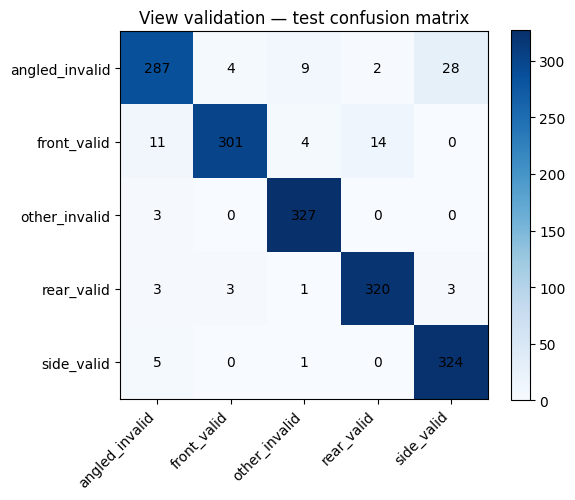

Saved: /Users/versache-karinndzi/Downloads/car-inspection-assistant/ml/quality_view/reports/view_validation_test_report.json


In [8]:

view_test_out = evaluate_model(view_model, view_test_loader, DEVICE)
view_report = classification_report(view_test_out["y_true"], view_test_out["y_pred"], target_names=view_test_ds.classes, output_dict=True)
view_cm = confusion_matrix(view_test_out["y_true"], view_test_out["y_pred"])
plot_confusion(view_cm, view_test_ds.classes, "View validation — test confusion matrix")

view_report_path = REPORTS_DIR / "view_validation_test_report.json"
view_report_path.write_text(json.dumps(view_report, indent=2), encoding="utf-8")
print("Saved:", view_report_path)

In [9]:

# Подбор confidence threshold: чем ниже false-accept по invalid, тем лучше.
valid_class_names = {"front_valid", "rear_valid", "side_valid"}
invalid_class_names = {"angled_invalid", "other_invalid"}
idx_to_name = {i: cls for i, cls in enumerate(view_test_ds.classes)}

def evaluate_view_threshold(val_out, threshold):
    probs = val_out["y_prob"]
    y_true = val_out["y_true"]
    pred_idx = probs.argmax(axis=1)
    pred_prob = probs.max(axis=1)

    false_accept = 0
    invalid_total = 0
    valid_recall_hits = 0
    valid_total = 0

    for yt, pi, pp in zip(y_true, pred_idx, pred_prob):
        yt_name = idx_to_name[int(yt)]
        pi_name = idx_to_name[int(pi)]
        accept = (pp >= threshold) and (pi_name in valid_class_names)
        if yt_name in invalid_class_names:
            invalid_total += 1
            if accept:
                false_accept += 1
        if yt_name in valid_class_names:
            valid_total += 1
            if accept and pi_name == yt_name:
                valid_recall_hits += 1

    return {
        "threshold": threshold,
        "false_accept_rate_invalid": false_accept / max(1, invalid_total),
        "strict_valid_recall": valid_recall_hits / max(1, valid_total),
    }

threshold_rows = [evaluate_view_threshold(view_best["val"], t) for t in VIEW_CFG["confidence_threshold_candidates"]]
threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

# Выбираем первый threshold с false_accept <= 0.10, иначе минимальный false_accept.
eligible = threshold_df[threshold_df["false_accept_rate_invalid"] <= 0.10]
if len(eligible) > 0:
    chosen_view_threshold = float(eligible.sort_values(["strict_valid_recall", "threshold"], ascending=[False, True]).iloc[0]["threshold"])
else:
    chosen_view_threshold = float(threshold_df.sort_values(["false_accept_rate_invalid", "strict_valid_recall"], ascending=[True, False]).iloc[0]["threshold"])

print("Chosen view threshold =", chosen_view_threshold)

,threshold,false_accept_rate_invalid,strict_valid_recall
0,0.40,0.034848,0.950505
1,0.45,0.033333,0.949495
2,0.50,0.030303,0.945455
3,0.55,0.027273,0.944444
4,0.60,0.025758,0.937374
5,0.65,0.024242,0.930303
6,0.70,0.021212,0.927273
7,0.75,0.016667,0.918182
8,0.80,0.015152,0.906061
9,0.85,0.013636,0.890909


Chosen view threshold = 0.4


In [10]:

view_weights_path = WEIGHTS_DIR / "view_validation_best.pt"
torch.save({
    "model_state_dict": view_model.state_dict(),
    "classes": view_train_ds.classes,
    "image_size": VIEW_CFG["image_size"],
    "threshold": chosen_view_threshold,
    "backbone": VIEW_CFG["model_name"],
    "best_epoch": view_best["epoch"],
    "best_val_macro_f1": view_best["score"],
}, view_weights_path)
print("Saved view weights to:", view_weights_path)

Saved view weights to: /Users/versache-karinndzi/Downloads/car-inspection-assistant/ml/quality_view/weights/view_validation_best.pt


## B. Обучение quality gate

In [11]:
quality_train_tfms = transforms.Compose([
    transforms.Resize((QUALITY_CFG["image_size"], QUALITY_CFG["image_size"])),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

quality_eval_tfms = transforms.Compose([
    transforms.Resize((QUALITY_CFG["image_size"], QUALITY_CFG["image_size"])),
    transforms.ToTensor(),
])

quality_train_ds = datasets.ImageFolder(QUALITY_DATASET_DIR / "train", transform=quality_train_tfms)
quality_val_ds = datasets.ImageFolder(QUALITY_DATASET_DIR / "val", transform=quality_eval_tfms)
quality_test_ds = datasets.ImageFolder(QUALITY_DATASET_DIR / "test", transform=quality_eval_tfms)

quality_sampler = build_weighted_sampler(quality_train_ds)

quality_loader_kwargs = {
    "num_workers": QUALITY_CFG["num_workers"],
    "pin_memory": DEVICE == "cuda",
}
if QUALITY_CFG["num_workers"] > 0:
    quality_loader_kwargs["persistent_workers"] = True

quality_train_loader = DataLoader(
    quality_train_ds,
    batch_size=QUALITY_CFG["batch_size"],
    sampler=quality_sampler,
    **quality_loader_kwargs,
)
quality_val_loader = DataLoader(
    quality_val_ds,
    batch_size=QUALITY_CFG["batch_size"],
    shuffle=False,
    **quality_loader_kwargs,
)
quality_test_loader = DataLoader(
    quality_test_ds,
    batch_size=QUALITY_CFG["batch_size"],
    shuffle=False,
    **quality_loader_kwargs,
)

print("Quality classes:", quality_train_ds.classes)
print("Train counts:", imagefolder_counts(quality_train_ds))
print("Val counts:  ", imagefolder_counts(quality_val_ds))
print("Test counts: ", imagefolder_counts(quality_test_ds))
print("Quality DataLoader kwargs:", quality_loader_kwargs)

Quality classes: ['accept', 'reject']
Train counts: {'accept': 3639, 'reject': 3639}
Val counts:   {'accept': 780, 'reject': 780}
Test counts:  {'accept': 781, 'reject': 781}
Quality DataLoader kwargs: {'num_workers': 0, 'pin_memory': False}


In [12]:

quality_model = create_model(QUALITY_CFG["model_name"], num_classes=len(quality_train_ds.classes)).to(DEVICE)
quality_model, quality_best = train_classifier(quality_model, quality_train_loader, quality_val_loader, QUALITY_CFG, DEVICE, "quality")

[quality] epoch=01 train_loss=0.9462 train_acc=0.8043 val_loss=0.2627 val_macro_f1=0.8991
[quality] epoch=02 train_loss=0.2891 train_acc=0.8857 val_loss=0.3029 val_macro_f1=0.8833
[quality] epoch=03 train_loss=0.2349 train_acc=0.9074 val_loss=0.2276 val_macro_f1=0.9121
[quality] epoch=04 train_loss=0.2143 train_acc=0.9162 val_loss=0.3151 val_macro_f1=0.8783
[quality] epoch=05 train_loss=0.2271 train_acc=0.9178 val_loss=0.2107 val_macro_f1=0.9160
[quality] epoch=06 train_loss=0.1787 train_acc=0.9351 val_loss=0.1924 val_macro_f1=0.9263
[quality] epoch=07 train_loss=0.1849 train_acc=0.9312 val_loss=0.2281 val_macro_f1=0.9092
[quality] epoch=08 train_loss=0.2141 train_acc=0.9235 val_loss=0.2092 val_macro_f1=0.9179
[quality] epoch=09 train_loss=0.1873 train_acc=0.9298 val_loss=0.1889 val_macro_f1=0.9288


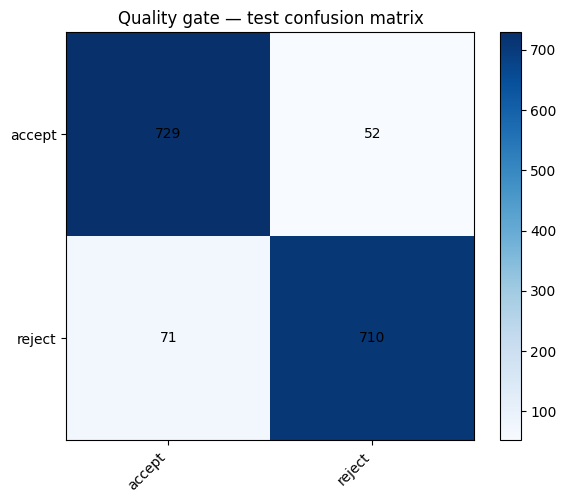

Saved: /Users/versache-karinndzi/Downloads/car-inspection-assistant/ml/quality_view/reports/quality_gate_test_report.json


In [13]:

quality_test_out = evaluate_model(quality_model, quality_test_loader, DEVICE)
quality_report = classification_report(quality_test_out["y_true"], quality_test_out["y_pred"], target_names=quality_test_ds.classes, output_dict=True)
quality_cm = confusion_matrix(quality_test_out["y_true"], quality_test_out["y_pred"])
plot_confusion(quality_cm, quality_test_ds.classes, "Quality gate — test confusion matrix")

quality_report_path = REPORTS_DIR / "quality_gate_test_report.json"
quality_report_path.write_text(json.dumps(quality_report, indent=2), encoding="utf-8")
print("Saved:", quality_report_path)

In [14]:

# Подбор порога reject по вероятности класса reject
quality_idx_to_name = {i: cls for i, cls in enumerate(quality_train_ds.classes)}
reject_index = quality_train_ds.class_to_idx["reject"]

def evaluate_quality_threshold(val_out, threshold):
    probs = val_out["y_prob"][:, reject_index]
    y_true = val_out["y_true"]

    pred_reject = probs >= threshold
    true_reject = y_true == reject_index

    reject_recall = (pred_reject & true_reject).sum() / max(1, true_reject.sum())
    false_reject = (pred_reject & (~true_reject)).sum() / max(1, (~true_reject).sum())
    bal_acc = balanced_accuracy_score(true_reject.astype(int), pred_reject.astype(int))
    return {
        "threshold": threshold,
        "reject_recall": float(reject_recall),
        "false_reject_rate": float(false_reject),
        "balanced_accuracy": float(bal_acc),
    }

quality_threshold_rows = [evaluate_quality_threshold(quality_best["val"], t) for t in QUALITY_CFG["reject_threshold_candidates"]]
quality_threshold_df = pd.DataFrame(quality_threshold_rows)
display(quality_threshold_df)

eligible = quality_threshold_df[(quality_threshold_df["reject_recall"] >= 0.90) & (quality_threshold_df["false_reject_rate"] <= 0.15)]
if len(eligible) > 0:
    chosen_quality_threshold = float(eligible.sort_values(["balanced_accuracy", "threshold"], ascending=[False, True]).iloc[0]["threshold"])
else:
    chosen_quality_threshold = float(quality_threshold_df.sort_values(["balanced_accuracy", "reject_recall"], ascending=[False, False]).iloc[0]["threshold"])

print("Chosen quality threshold =", chosen_quality_threshold)

,threshold,reject_recall,false_reject_rate,balanced_accuracy
0,0.30,0.957692,0.160256,0.898718
1,0.35,0.953846,0.138462,0.907692
2,0.40,0.946154,0.117949,0.914103
3,0.45,0.939744,0.096154,0.921795
4,0.50,0.933333,0.075641,0.928846
5,0.55,0.923077,0.062821,0.930128
6,0.60,0.914103,0.055128,0.929487
7,0.65,0.901282,0.041026,0.930128
8,0.70,0.891026,0.025641,0.932692
9,0.75,0.879487,0.020513,0.929487


Chosen quality threshold = 0.55


In [15]:

quality_weights_path = WEIGHTS_DIR / "quality_gate_best.pt"
torch.save({
    "model_state_dict": quality_model.state_dict(),
    "classes": quality_train_ds.classes,
    "image_size": QUALITY_CFG["image_size"],
    "reject_threshold": chosen_quality_threshold,
    "backbone": QUALITY_CFG["model_name"],
    "best_epoch": quality_best["epoch"],
    "best_val_macro_f1": quality_best["score"],
}, quality_weights_path)

summary = {
    "view_weights": str(view_weights_path),
    "quality_weights": str(quality_weights_path),
    "reports_dir": str(REPORTS_DIR),
}
summary_path = REPORTS_DIR / "training_summary.json"
summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")

print("Saved quality weights to:", quality_weights_path)
print("Saved summary to:", summary_path)

Saved quality weights to: /Users/versache-karinndzi/Downloads/car-inspection-assistant/ml/quality_view/weights/quality_gate_best.pt
Saved summary to: /Users/versache-karinndzi/Downloads/car-inspection-assistant/ml/quality_view/reports/training_summary.json
